In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch import nn
from torchvision import datasets, transforms
import os
from PIL import Image
from pathlib import Path

In [2]:
data_path = Path("data/")

In [3]:
dataset_path = data_path / "flowers"

In [4]:
dataset_path

WindowsPath('data/flowers')

In [5]:
from torchvision.datasets import ImageFolder

In [6]:
train_dir = dataset_path / "train"
test_dir = dataset_path / "test"

In [7]:
train_dir

WindowsPath('data/flowers/train')

In [8]:
test_dir

WindowsPath('data/flowers/test')

In [9]:
from torch.utils.data import DataLoader

In [10]:
train_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.462287575006485, 0.4222007393836975, 0.3023022711277008],
    std=[0.24355322122573853, 0.21776461601257324, 0.22300653159618378]
)
])

val_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.462287575006485, 0.4222007393836975, 0.3023022711277008],
    std=[0.24355322122573853, 0.21776461601257324, 0.22300653159618378]
)
])

test_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.462287575006485, 0.4222007393836975, 0.3023022711277008],
    std=[0.24355322122573853, 0.21776461601257324, 0.22300653159618378]
)
])

In [11]:
dataset = datasets.ImageFolder(
        root=train_dir
)

In [12]:
from torch.utils.data import random_split

In [13]:
train_size = int(0.7 *len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

In [14]:
train_data = datasets.ImageFolder(
    train_dir,
    transform = train_transform)

val_data = datasets.ImageFolder(
    train_dir,
    transform = val_transform)

test_data = datasets.ImageFolder(
    train_dir,
    transform = test_transform)

In [15]:
train_indices = train_dataset.indices
val_indices = val_dataset.indices
test_indices = test_dataset.indices

In [16]:
from torch.utils.data import Subset

In [17]:
train_dataset = Subset(train_data, train_indices)
val_dataset = Subset(val_data, val_indices)
test_dataset = Subset(test_data, test_indices)

In [18]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [19]:
class_names = train_data.classes

In [20]:
class_names

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

In [21]:
'''
def calculate_dataset_statistics(
    dataset_path,
    image_size=(224, 224),
    batch_size=32,
    num_workers=0,
):
    """
    Bir ImageFolder dataset'i için RGB mean ve std hesaplar.

    Args:
        dataset_path (str): Dataset klasör yolu.
        image_size (tuple): Resize edilecek boyut.
        batch_size (int): DataLoader batch size.
        num_workers (int): DataLoader worker sayısı.

    Returns:
        mean (Tensor)
        std (Tensor)
    """

    # Sadece Resize ve ToTensor uygulanır.
    # Normalize uygulanmaz!
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor()
    ])

    dataset = datasets.ImageFolder(
        root=dataset_path,
        transform=transform
    )

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_images = 0

    for images, _ in dataloader:

        # (B,C,H,W) -> (B,C,H*W)
        images = images.view(images.size(0), images.size(1), -1)

        mean += images.mean(dim=2).sum(dim=0)
        std += images.std(dim=2).sum(dim=0)

        total_images += images.size(0)

    mean /= total_images
    std /= total_images

    print("=" * 50)
    print(f"Dataset Path : {dataset_path}")
    print(f"Toplam Resim : {len(dataset)}")
    print(f"Sınıflar     : {dataset.classes}")
    print(f"Image Size   : {image_size}")
    print("=" * 50)

    print("\nMean:")
    print(mean)

    print("\nStd:")
    print(std)

    print("\nKopyala-Yapıştır Normalize:")
    print(f"""
transforms.Normalize(
    mean={mean.tolist()},
    std={std.tolist()}
)
""")

    return mean, std
mean, std = calculate_dataset_statistics(
    "data/flowers/train",
    image_size=(224,224)
)
# kullanım için data yolunu ve image_size değerini değiştirmek yeterli olur

'''

'\ndef calculate_dataset_statistics(\n    dataset_path,\n    image_size=(224, 224),\n    batch_size=32,\n    num_workers=0,\n):\n    """\n    Bir ImageFolder dataset\'i için RGB mean ve std hesaplar.\n\n    Args:\n        dataset_path (str): Dataset klasör yolu.\n        image_size (tuple): Resize edilecek boyut.\n        batch_size (int): DataLoader batch size.\n        num_workers (int): DataLoader worker sayısı.\n\n    Returns:\n        mean (Tensor)\n        std (Tensor)\n    """\n\n    # Sadece Resize ve ToTensor uygulanır.\n    # Normalize uygulanmaz!\n    transform = transforms.Compose([\n        transforms.Resize(image_size),\n        transforms.ToTensor()\n    ])\n\n    dataset = datasets.ImageFolder(\n        root=dataset_path,\n        transform=transform\n    )\n\n    dataloader = DataLoader(\n        dataset,\n        batch_size=batch_size,\n        shuffle=False,\n        num_workers=num_workers\n    )\n\n    mean = torch.zeros(3)\n    std = torch.zeros(3)\n    total_imag

In [22]:
import torchvision

In [23]:
weights = torchvision.models.EfficientNet_B1_Weights.DEFAULT

In [24]:
weights

EfficientNet_B1_Weights.IMAGENET1K_V2

In [25]:
torch.cuda.is_available()

True

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [27]:
device

'cuda'

In [28]:
model = torchvision.models.efficientnet_b1(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to C:\Users\rarsl/.cache\torch\hub\checkpoints\efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:01<00:00, 24.3MB/s]


In [29]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [30]:
from torchinfo import summary

In [31]:
summary(model=model,
        input_size=(32,3,240,240),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 240, 240]         [32, 1000]                --                        True
├─Sequential: 1-1                                       [32, 3, 240, 240]         [32, 1280, 8, 8]          --                        True
│    └─Conv2dNormActivation: 2-1                        [32, 3, 240, 240]         [32, 32, 120, 120]        --                        True
│    │    └─Conv2d: 3-1                                 [32, 3, 240, 240]         [32, 32, 120, 120]        864                       True
│    │    └─BatchNorm2d: 3-2                            [32, 32, 120, 120]        [32, 32, 120, 120]        64                        True
│    │    └─SiLU: 3-3                                   [32, 32, 120, 120]        [32, 32, 120, 120]        --                        --
│    └─Sequential: 2-2  

In [32]:
for param in model.features.parameters():
    param.requires_grad = False

In [33]:
summary(model=model,
        input_size=(32,3,240,240),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 240, 240]         [32, 1000]                --                        Partial
├─Sequential: 1-1                                       [32, 3, 240, 240]         [32, 1280, 8, 8]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 240, 240]         [32, 32, 120, 120]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 240, 240]         [32, 32, 120, 120]        (864)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 120, 120]        [32, 32, 120, 120]        (64)                      False
│    │    └─SiLU: 3-3                                   [32, 32, 120, 120]        [32, 32, 120, 120]        --                        --
│    └─Sequential

In [34]:
output_shape = len(class_names)

In [35]:
output_shape

5

In [36]:
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.3, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=output_shape, bias =True)
).to(device)

In [37]:
summary(model=model,
        input_size=(32,3,240,240),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 240, 240]         [32, 5]                   --                        Partial
├─Sequential: 1-1                                       [32, 3, 240, 240]         [32, 1280, 8, 8]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 240, 240]         [32, 32, 120, 120]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 240, 240]         [32, 32, 120, 120]        (864)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 120, 120]        [32, 32, 120, 120]        (64)                      False
│    │    └─SiLU: 3-3                                   [32, 32, 120, 120]        [32, 32, 120, 120]        --                        --
│    └─Sequential

In [38]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [39]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(),lr=0.001,weight_decay=0.0001)

In [46]:
from tqdm.auto import tqdm

In [49]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device : device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(tqdm(dataloader)):

        X = X.to(device)
        y = y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def val_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device : torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    val_loss, val_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):

            X = X.to(device)
            y = y.to(device)
            # 1. Forward pass
            val_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(val_pred_logits, y)
            val_loss += loss.item()

            # Calculate and accumulate accuracy
            val_pred_labels = val_pred_logits.argmax(dim=1)
            val_acc += ((val_pred_labels == y).sum().item() / len(val_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    val_loss = val_loss / len(dataloader)
    val_acc = val_acc / len(dataloader)
    return val_loss, val_acc



def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device : torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):

            X = X.to(device)
            y = y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device : torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "val_loss": [],
               "val_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device = device)
        val_loss, val_acc = val_step(model=model,
                                        dataloader=val_dataloader,
                                        loss_fn=loss_fn,
                                        device = device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["val_loss"].append(val_loss.item() if isinstance(val_loss, torch.Tensor) else val_loss)
        results["val_acc"].append(val_acc.item() if isinstance(val_acc, torch.Tensor) else val_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [50]:
results = train(model=model,
                train_dataloader=train_dataloader,
                val_dataloader=val_dataloader,
                optimizer = optimizer,
                loss_fn = loss_fn,
                device=device,
                epochs=10)

100%|██████████| 61/61 [00:19<00:00,  3.17it/s]


Epoch: 1 | train_loss: 0.8261 | train_acc: 0.8151 | val_loss: 0.6868 | val_acc: 0.8393


100%|██████████| 61/61 [00:18<00:00,  3.23it/s]


Epoch: 2 | train_loss: 0.6565 | train_acc: 0.8212 | val_loss: 0.5641 | val_acc: 0.8616


100%|██████████| 61/61 [00:19<00:00,  3.20it/s]


...

Epoch: 8 | train_loss: 0.4195 | train_acc: 0.8755 | val_loss: 0.3849 | val_acc: 0.8887


100%|██████████| 61/61 [00:19<00:00,  3.20it/s]


Epoch: 9 | train_loss: 0.4263 | train_acc: 0.8694 | val_loss: 0.3502 | val_acc: 0.9008


100%|██████████| 61/61 [00:18<00:00,  3.22it/s]


Epoch: 10 | train_loss: 0.4131 | train_acc: 0.8832 | val_loss: 0.3578 | val_acc: 0.8929


In [52]:
train_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.RandomResizedCrop(240, scale=(0.6, 1.0)),
    transforms.RandomPerspective(
    distortion_scale=0.2,
    p=0.3
),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.462287575006485, 0.4222007393836975, 0.3023022711277008],
    std=[0.24355322122573853, 0.21776461601257324, 0.22300653159618378]
)
])

val_transform = transforms.Compose([
    transforms.Resize((240, 240)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.462287575006485, 0.4222007393836975, 0.3023022711277008],
    std=[0.24355322122573853, 0.21776461601257324, 0.22300653159618378]
)
])

In [53]:
train_data = datasets.ImageFolder(
    train_dir,
    transform = train_transform)

val_data = datasets.ImageFolder(
    train_dir,
    transform = val_transform)

In [54]:
train_dataset = Subset(train_data, train_indices)
val_dataset = Subset(val_data, val_indices)

In [56]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [57]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [59]:
summary(model=model,
        input_size=(32,3,240,240),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 240, 240]         [32, 5]                   --                        Partial
├─Sequential: 1-1                                       [32, 3, 240, 240]         [32, 1280, 8, 8]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 240, 240]         [32, 32, 120, 120]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 240, 240]         [32, 32, 120, 120]        (864)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 120, 120]        [32, 32, 120, 120]        (64)                      False
│    │    └─SiLU: 3-3                                   [32, 32, 120, 120]        [32, 32, 120, 120]        --                        --
│    └─Sequential

In [60]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(),lr=0.0001,weight_decay=0.00001)

In [61]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device : device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(tqdm(dataloader)):

        X = X.to(device)
        y = y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def val_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device : torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    val_loss, val_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):

            X = X.to(device)
            y = y.to(device)
            # 1. Forward pass
            val_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(val_pred_logits, y)
            val_loss += loss.item()

            # Calculate and accumulate accuracy
            val_pred_labels = val_pred_logits.argmax(dim=1)
            val_acc += ((val_pred_labels == y).sum().item() / len(val_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    val_loss = val_loss / len(dataloader)
    val_acc = val_acc / len(dataloader)
    return val_loss, val_acc



def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device : torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):

            X = X.to(device)
            y = y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device : torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "val_loss": [],
               "val_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device = device)
        val_loss, val_acc = val_step(model=model,
                                        dataloader=val_dataloader,
                                        loss_fn=loss_fn,
                                        device = device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"val_acc: {val_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["val_loss"].append(val_loss.item() if isinstance(val_loss, torch.Tensor) else val_loss)
        results["val_acc"].append(val_acc.item() if isinstance(val_acc, torch.Tensor) else val_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [62]:
results = train(model=model,
                train_dataloader=train_dataloader,
                val_dataloader=val_dataloader,
                optimizer = optimizer,
                loss_fn = loss_fn,
                device=device,
                epochs=10)

100%|██████████| 121/121 [00:25<00:00,  4.82it/s]


Epoch: 1 | train_loss: 0.4175 | train_acc: 0.8791 | val_loss: 0.4123 | val_acc: 0.8846


100%|██████████| 121/121 [00:25<00:00,  4.80it/s]


Epoch: 2 | train_loss: 0.4077 | train_acc: 0.8853 | val_loss: 0.4035 | val_acc: 0.8942


100%|██████████| 121/121 [00:25<00:00,  4.76it/s]


...

Epoch: 8 | train_loss: 0.3921 | train_acc: 0.8822 | val_loss: 0.3993 | val_acc: 0.8750


100%|██████████| 121/121 [00:25<00:00,  4.83it/s]


Epoch: 9 | train_loss: 0.3721 | train_acc: 0.8900 | val_loss: 0.3775 | val_acc: 0.8822


100%|██████████| 121/121 [00:25<00:00,  4.82it/s]


Epoch: 10 | train_loss: 0.3816 | train_acc: 0.8910 | val_loss: 0.3800 | val_acc: 0.8942


In [63]:
test_loss,test_acc = test_step(model = model,
                               dataloader = test_dataloader,
                               loss_fn = loss_fn,
                               device = device)

print(f"Final test loss: {test_loss}:.4f")
print(f"Final test accuracy: {test_acc}:.4f")

Final test loss: 0.3910199976884402:.4f
Final test accuracy: 0.8881797082228117:.4f


In [64]:
from typing import Tuple, List

In [65]:
def transform_predict(model: nn.Module,
                      image_path: str,
                      class_names: List[str],
                      image_size: Tuple[int,int] = (224,224),
                      transform: torchvision.transforms = None,
                      device: torch.device = device):
    img = Image.open(image_path).convert("RGB")

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.462287575006485, 0.4222007393836975, 0.3023022711277008],
    std=[0.24355322122573853, 0.21776461601257324, 0.22300653159618378])
        ])

    # Bu blok artık if/else'in DIŞINDA, her durumda çalışır
    model.to(device)
    model.eval()
    with torch.inference_mode():
        transformed_image = image_transform(img).unsqueeze(dim=0)
        target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]}, Prob: {target_image_pred_probs.max():.3f}")
    plt.axis("off")

In [66]:
class_names

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

In [67]:
image_path = data_path / "rose.jpg"

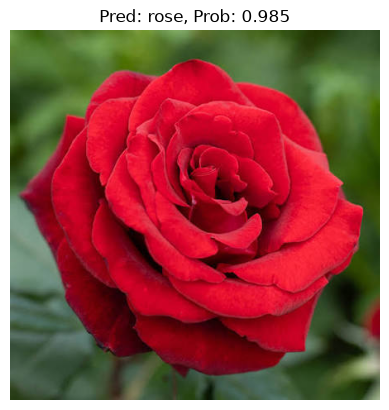

In [68]:
transform_predict(model,image_path,class_names)

In [69]:
image_path2 = data_path / "sunflower.jpg"

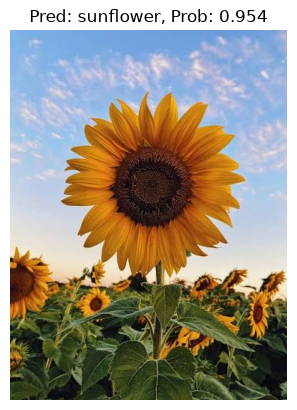

In [70]:
transform_predict(model,image_path2,class_names)

In [71]:
image_path3 = data_path / "daisy.jpg"

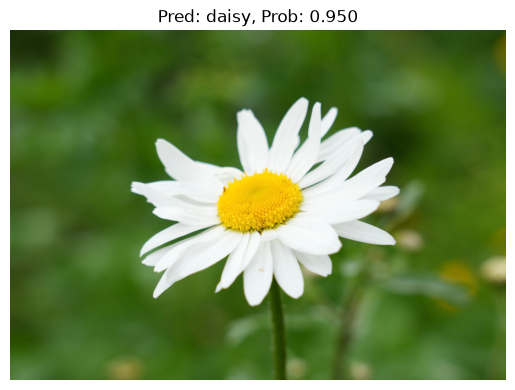

In [72]:
transform_predict(model,image_path3,class_names)

In [74]:
image_path4 = data_path / "dandelion.jpg"

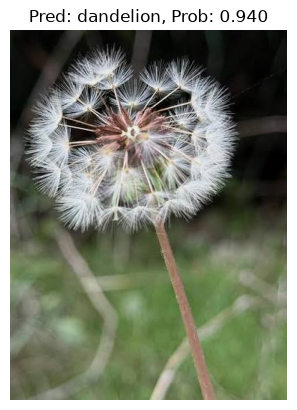

In [75]:
transform_predict(model,image_path4,class_names)

In [76]:
image_path5 = data_path / "tulip.jpg"

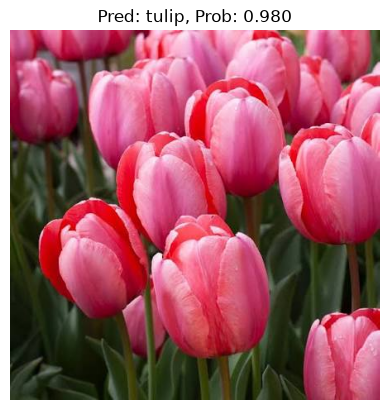

In [77]:
transform_predict(model,image_path5,class_names)